In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


(768, 9)

In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for c in cols:
    df[c] = df[c].replace(0, df[c].median())

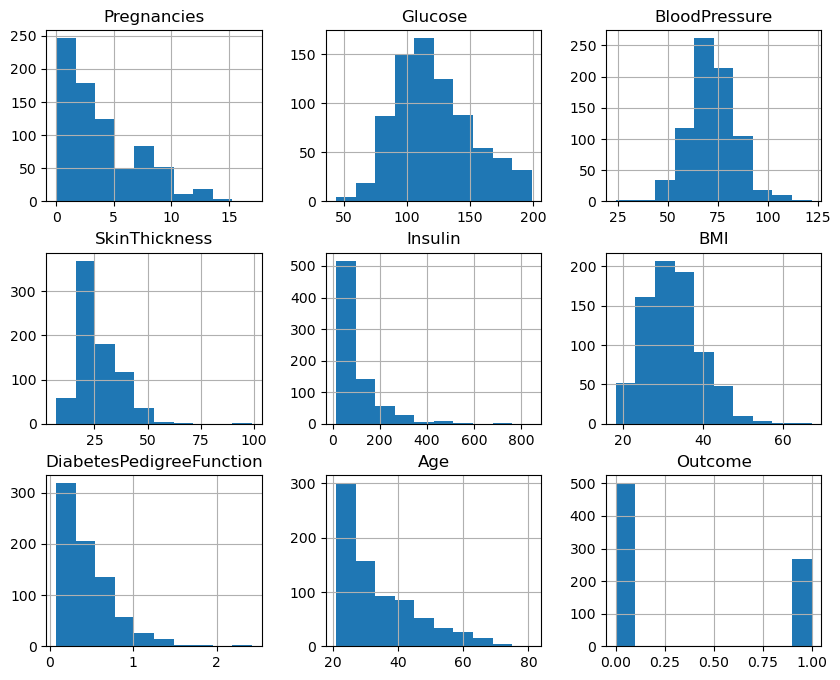

In [7]:
df.hist(figsize=(10,8))
plt.show()

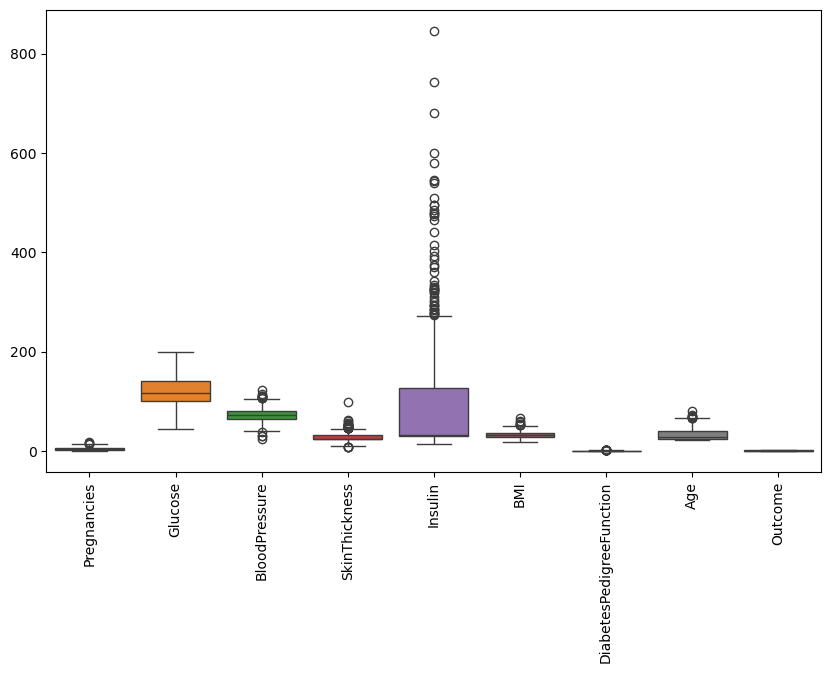

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

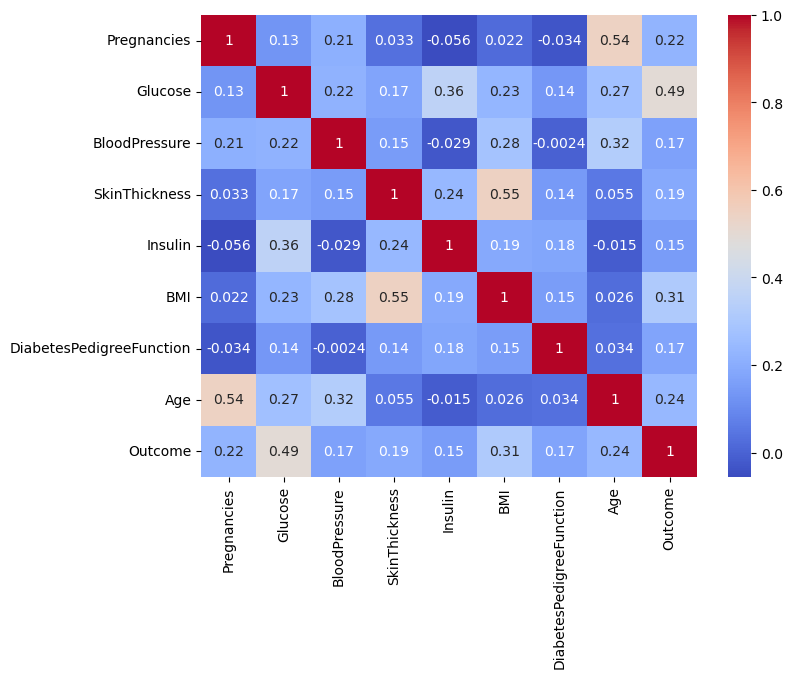

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

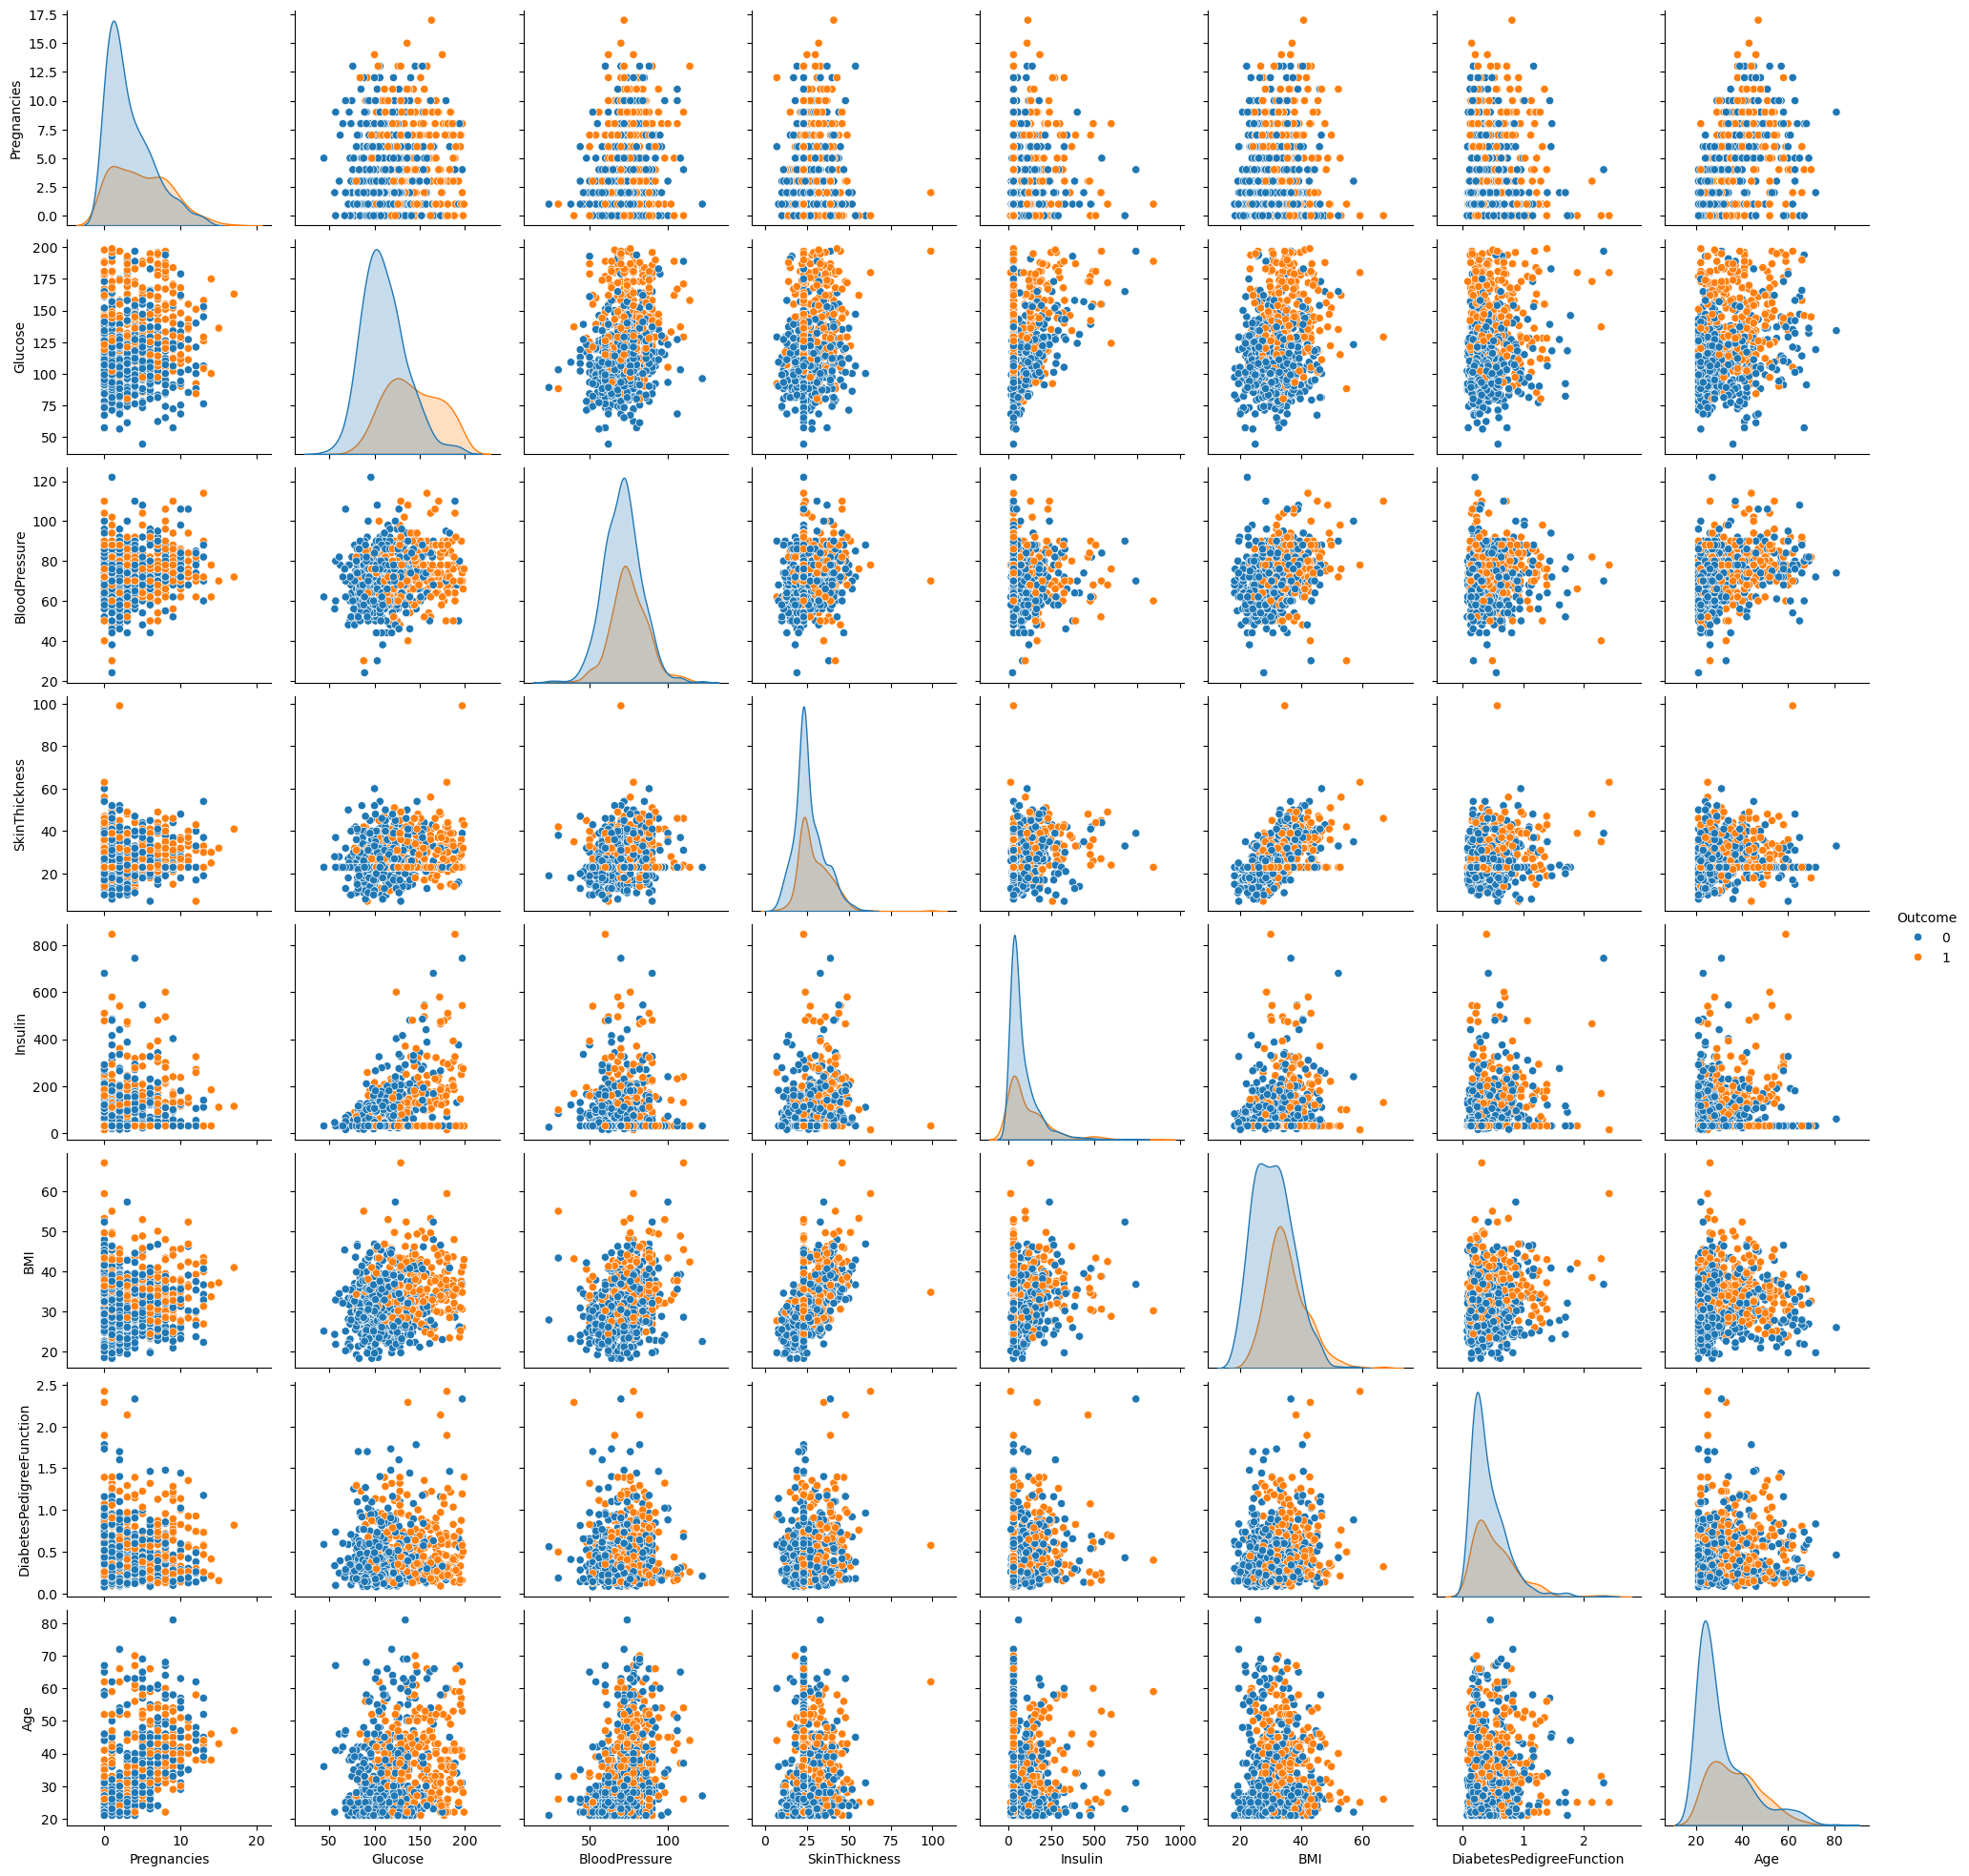

In [10]:
sns.pairplot(df, hue="Outcome")
plt.show()

In [11]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.74675325 0.73376623 0.76623377 0.79738562 0.77777778]
Average CV Score: 0.7643833290892115


In [15]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7662337662337663
Precision: 0.6792452830188679
Recall: 0.6545454545454545
F1 Score: 0.6666666666666666


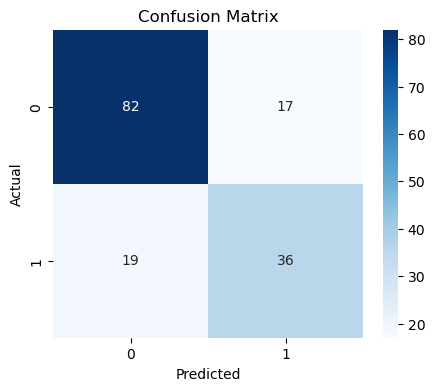

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        99
           1       0.68      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



ROC-AUC Score: 0.8196510560146923


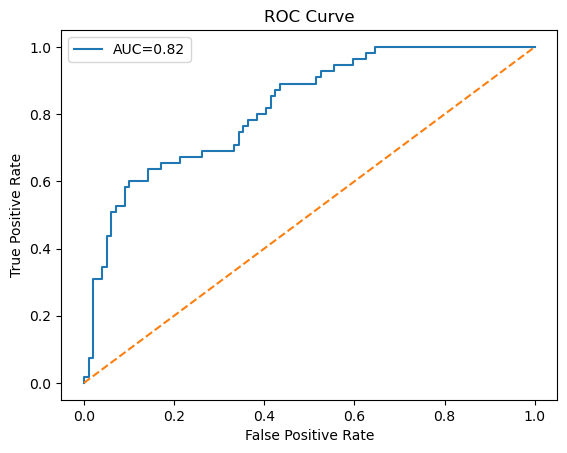

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc)
plt.plot(fpr, tpr, label="AUC=" + str(round(auc,2)))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve")
plt.show()

In [20]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
1,Glucose,1.138214
5,BMI,0.718367
7,Age,0.378817
0,Pregnancies,0.218415
6,DiabetesPedigreeFunction,0.216745
3,SkinThickness,0.049443
2,BloodPressure,-0.165564
4,Insulin,-0.224917


In [21]:
import pickle

pickle.dump(model, open("diabetes_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [22]:

"""
Q1.Precision:
Out of predicted positive cases,
how many are actually positive.

Formula:
TP / (TP + FP)

Recall:
Out of actual positive cases,
how many are correctly predicted.

Formula:
TP / (TP + FN)
"""

'\nQ1.Precision:\nOut of predicted positive cases,\nhow many are actually positive.\n\nFormula:\nTP / (TP + FP)\n\nRecall:\nOut of actual positive cases,\nhow many are correctly predicted.\n\nFormula:\nTP / (TP + FN)\n'

In [23]:

"""
Q2. What is Cross Validation?

Cross validation is a technique used
to evaluate model performance by
splitting data into multiple parts.

Importance:
- Reduces overfitting
- Gives better model evaluation
- Improves model reliability
"""

'\nQ2. What is Cross Validation?\n\nCross validation is a technique used\nto evaluate model performance by\nsplitting data into multiple parts.\n\nImportance:\n- Reduces overfitting\n- Gives better model evaluation\n- Improves model reliability\n'